# ASTR 8060 (Observational Methods) Sp26 Homework 4 
## Harrison Blake-Goszyk

--------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 1): Start a Jupyter notebook that will contain all sort of things you will learn in the course of your data analysis. Keep here your procedures that you run so that you can quickly re-run them with a few keystrokes. Also keep here anything you’d keep in a paper logbook regarding notes about your reduction. Markdown in your Jupyter notebook will take the place of formal reduction notes. The quality of the this file will make up one component of the grade for this homework.

Gotcha! Here is my notebook. I'll keep my notes about reduction and anything else I'm thinking throughout my thought process in here. Hope you enjoy!

--------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 2): Examine the images in DS9 to become familiar with where the overscan region of the chip is (on both sides of the data section; make note of where this is). Look at examples of bias images, dark images, and flats so that you can know by inspection what kind of image you are viewing.

Sounds good! For the sake of visualization and accuracy, I'm going to try plotting these guys for you and I to look at. Hope you enjoy!

Inside the "Imaging" directory I put all of the SAO files in, there's this one file called "log.txt" that has a pretty good record of what every file in the observing run is (Jessie's name is in there, too!). I can tell you that a005-10 are the flats (not sure what the tracking part means (I think tracking the rotation of the Earth vs the sky)), and that a093-111 are our bias images. Also, g01-05 are closed-dome flats while g06-25 are biases. Not sure which are the darks, but we'll figure it out. ANYWAY, here are some pretty plots of what I'm talking about:

In [ ]:
# Import block
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
%matplotlib inline
from astropy.visualization import ZScaleInterval, ImageNormalize

# Imaging data directory (SEE COMMENT BELOW!!)
data_dir = '/Users/blakeghg/Documents/Work/Courses!/Observational_Methods/Imaging/'

Note that you should change the data_dir to wherever you've stored the SAO DS9 images from Jessie's observation run locally on your machine. No way in hell I'm uploading all 2 GB that!

Here's a function we can use to open our files and give us the info we want:

In [8]:
def open_image(data_dir, filename):
    hdu = fits.open(data_dir + filename) # The call to open the file
    hdr = hdu[0].header # Getting the header of the file for checking purposes
    img = hdu[0].data # Getting the actual data we will work with
    return hdu, hdr, img

Here, I'll define a function we can use to plot all our images:

In [23]:
def plot_image(filename, img):
    
    # Scaling the color of the image by the photon count in the data
    interval = ZScaleInterval() # https://docs.astropy.org/en/latest/api/astropy.visualization.ZScaleInterval.html
    vmin, vmax = interval.get_limits(img) # The limits we'll stick into our color bar

    # Extracting the image dimensions
    ydim, xdim = img.shape # Getting the dimensions of the image

    # Plotting our image
    fig = plt.subplots(1,1,figsize=(8,8))
    plt.imshow(img, vmin=vmin, vmax=vmax, cmap='gray') # The plotting of the image with the color scaling we set above

    # Establisting the x and y ticks
    plt.xticks(np.arange(0, xdim, step=500)) # Setting the x ticks to be every 500 pixels
    plt.yticks(np.arange(0, ydim, step=500)) # Setting the y ticks to be every 500 pixels

    # Establishing the labels for the axes
    plt.xlabel('x pixel')
    plt.ylabel('y pixel')

    # Title, color bar, and grid
    plt.title(f'{filename} counts')
    plt.colorbar(label='Photon Counts')
    plt.grid(False)

    # Showin the image
    plt.show()

Now, let's open one of the flats and plot it!

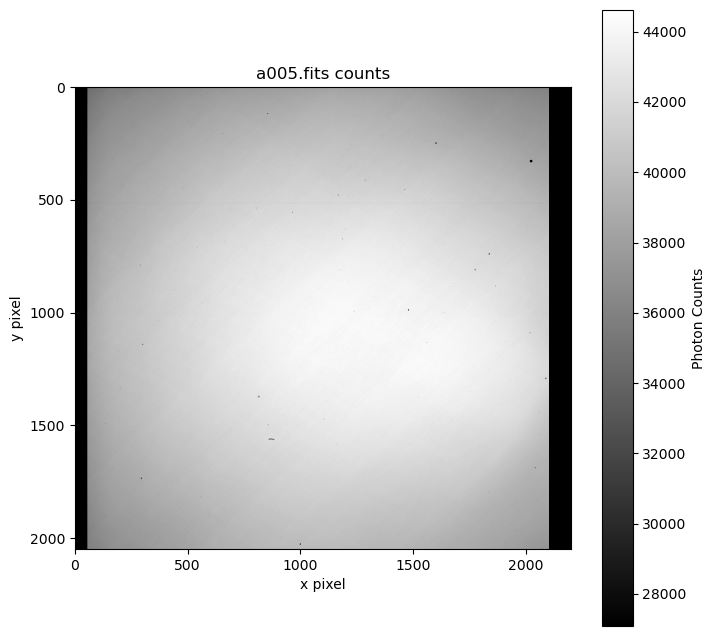

In [24]:
# File name
flat1_filename = 'a005.fits'

# Opening the image
hdu_flat1, hdr_flat1, img_flat1 = open_image(data_dir, flat1_filename)

# Plotting the image
plot_image(flat1_filename, img_flat1)

LETS GOOOO!!! We got our flat!! I'll be adjusting/refactoring the functions above as I go, so keep an eye out! Anyways. Let's do one of our biases!

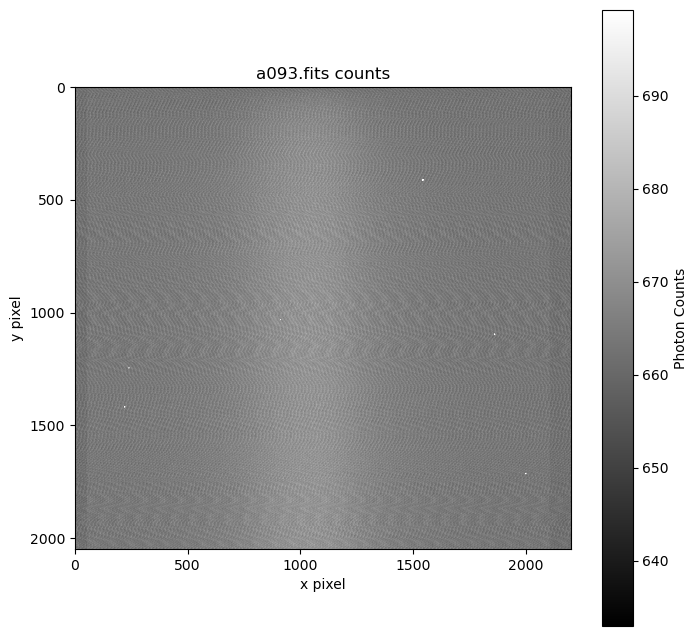

In [25]:
# File name
bias1_filename = 'a093.fits'

# Opening the image
hdu_bias1, hdr_bias1, img_bias1 = open_image(data_dir, bias1_filename)

# Plotting the image
plot_image(bias1_filename, img_bias1)

Interesting. Now, let's figure out which of these are darks... I'm going to define a new function to make this process a little quicker:

In [26]:
def rapid_fits_image(filenames):
    for filename in filenames:
        _, _, img = open_image(data_dir, str(filename)) # Opening the image
        plot_image(str(filename),img) # Plotting the image!

Perfect! Now, let's see which ones are what we want!

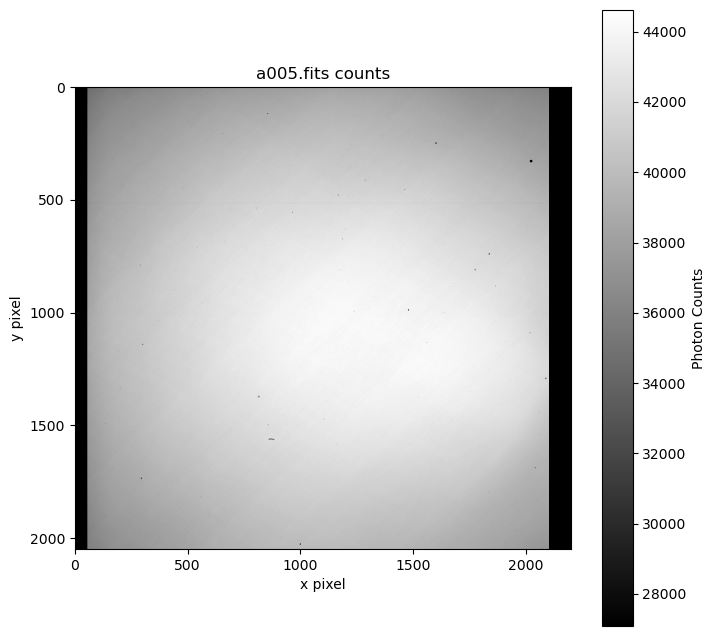

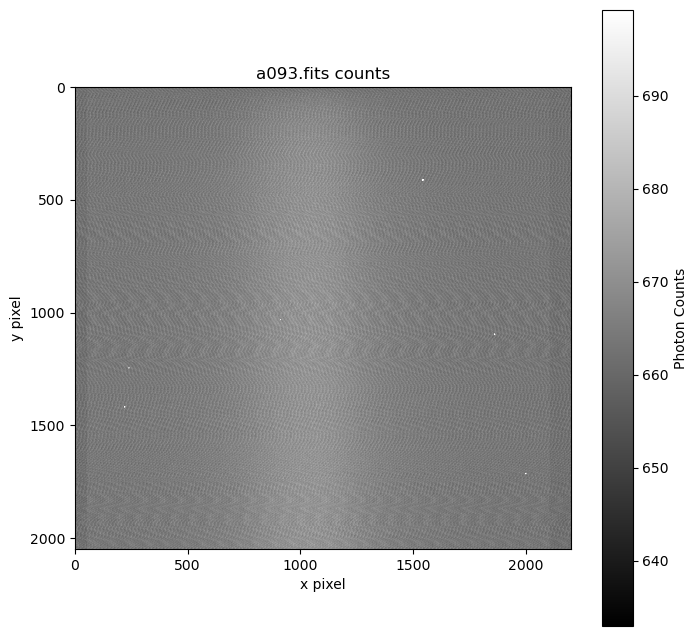

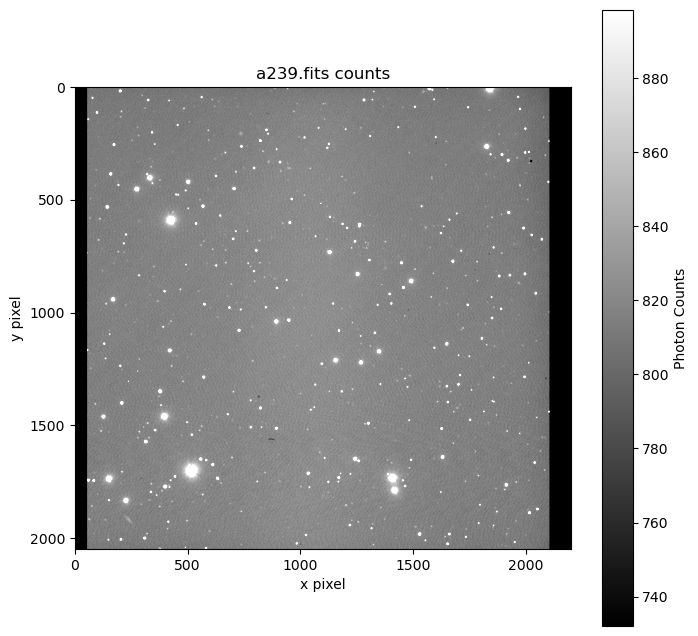

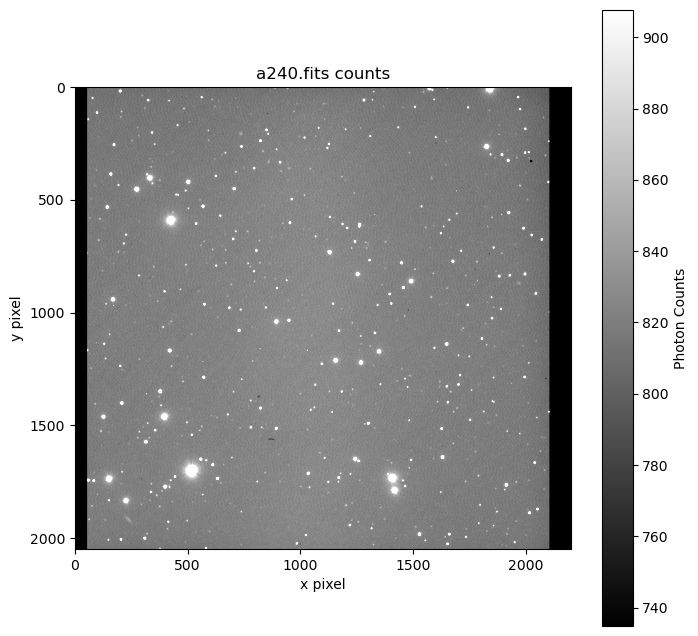

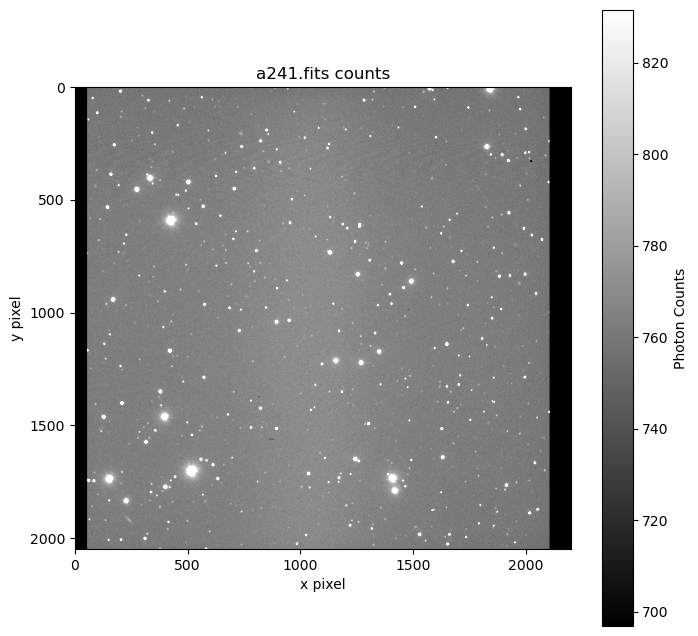

In [27]:
filenames_list1 = ['a005.fits', 'a093.fits', 'a239.fits', 'a240.fits', 'a241.fits']
rapid_fits_image(filenames_list1)

Hmmm... no luck so far. I'm also going to add a variable that changes the image size on these. Here's the edit!

In [ ]:
def plot_image_refactored(filename, img, width, height):
    
    # Scaling the color of the image by the photon count in the data
    interval = ZScaleInterval() # https://docs.astropy.org/en/latest/api/astropy.visualization.ZScaleInterval.html
    vmin, vmax = interval.get_limits(img) # The limits we'll stick into our color bar

    # Extracting the image dimensions
    ydim, xdim = img.shape # Getting the dimensions of the image

    # Plotting our image
    fig = plt.subplots(1,1,figsize=(width, height))
    plt.imshow(img, vmin=vmin, vmax=vmax, cmap='gray') # The plotting of the image with the color scaling we set above

    # Establisting the x and y ticks
    plt.xticks(np.arange(0, xdim, step=500)) # Setting the x ticks to be every 500 pixels
    plt.yticks(np.arange(0, ydim, step=500)) # Setting the y ticks to be every 500 pixels

    # Establishing the labels for the axes
    plt.xlabel('x pixel')
    plt.ylabel('y pixel')

    # Title, color bar, and grid
    plt.title(f'{filename} counts')
    plt.colorbar(label='Photon Counts')
    plt.grid(False)

    # Show the image
    plt.show()

def rapid_fits_image_refactored(filenames, width, height):
    for filename in filenames:
        _, _, img = open_image(data_dir, str(filename)) # Opening the image
        plot_image_refactored(filename, img, width, height) # Plotting the image!

Ok! Here we go! I'm going to pick based on log.txt, since the second column sometimes has onjects and sometimes does not. Maybe that means they're darks?

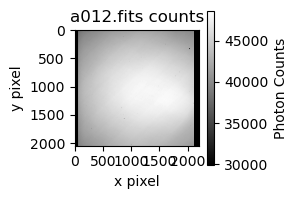

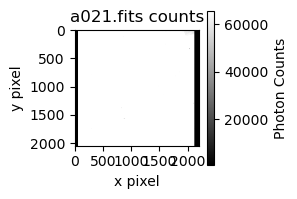

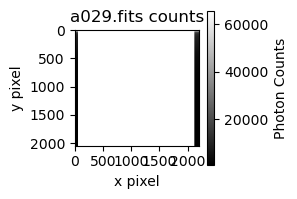

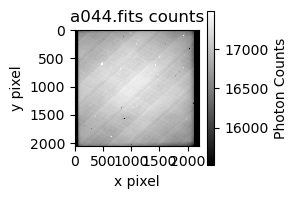

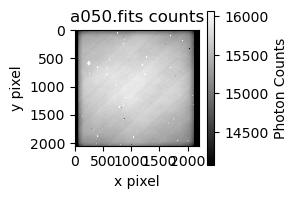

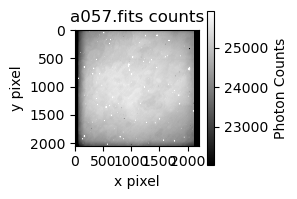

In [29]:
filenames_list2 = ['a012.fits', 'a021.fits', 'a029.fits', 'a044.fits', 'a050.fits', 'a057.fits']
rapid_fits_image_refactored(filenames_list2, width=2, height=2)

WAIT!!! Oh my Lord!! On log.txt, it says that d01-15 are darks!! Woohoo! At least I learned a littl emore abotu plotting these!! Here's a few dark images for you:

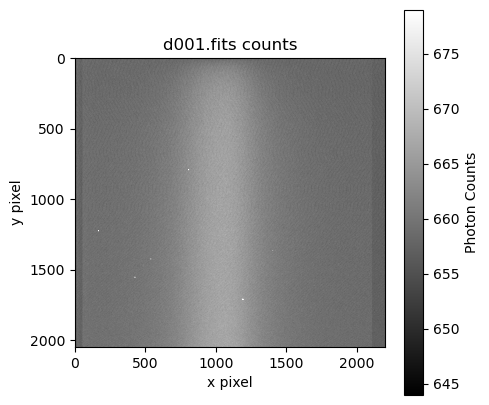

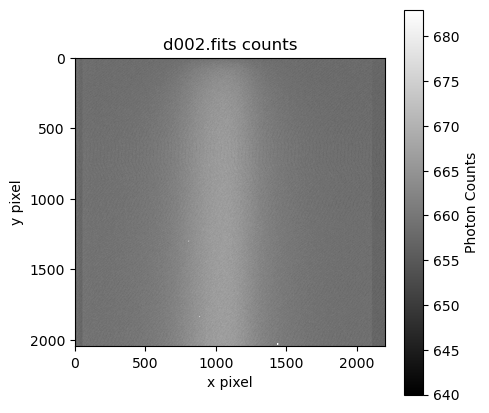

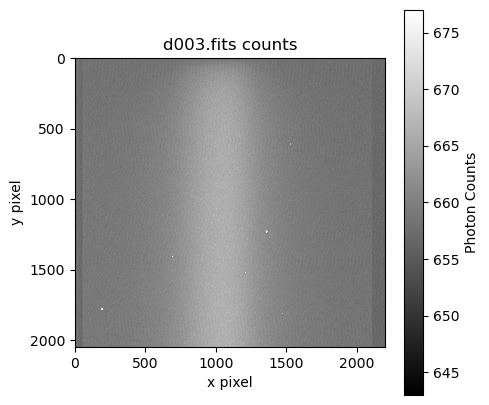

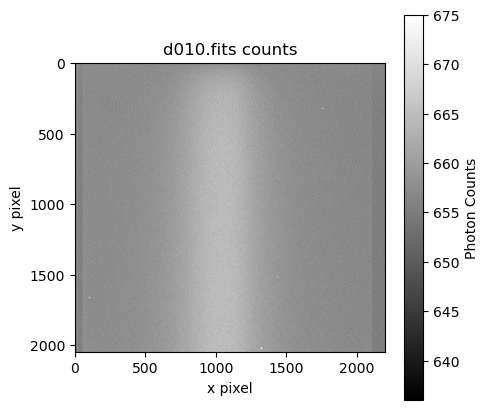

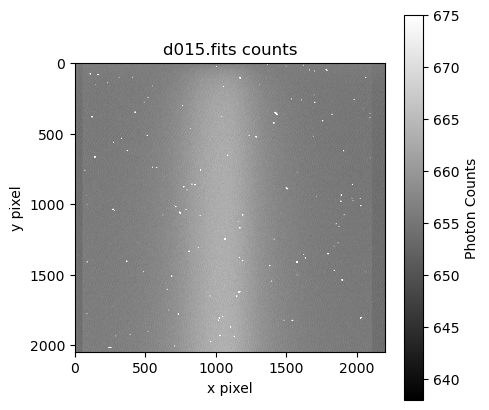

In [30]:
filenames_list3 = ['d001.fits', 'd002.fits', 'd003.fits', 'd010.fits', 'd015.fits']
rapid_fits_image_refactored(filenames_list3, width=5, height=5)

Very cool! You can see the overscan regions on the left and right of these images, usually totally balck in our color mapping. I also feel WAAAAAY more comfortable with the differences between baises, darks, and flats, as well as plotting them in python. Nice! Moving on!

--------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 3): Assess the RMS and mean levels of an image. Use Python to practice plotting lines and columns of data from one of the bias images. Use Python to compute the mean and RMS of a region near the center of the chip.

Sounds good! I'm going to pick M101 (the Pinwheel Galaxy) since it's pretty and I like it. Here's the image itself:

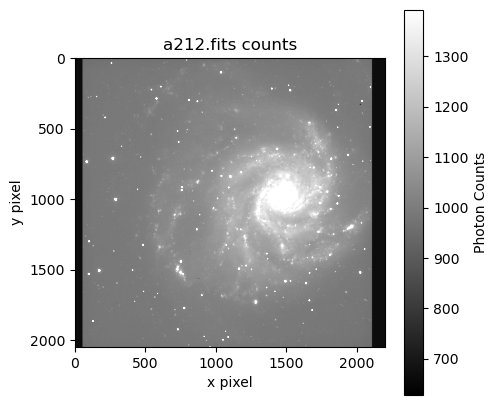

In [31]:
rapid_fits_image_refactored(['a212.fits'], width=5, height=5)

WOAH!!! That's crazy!!! Very cool :)

The impression I'm getting from the following websites is to use astropy's sigma_clipped_stats feature to get the rms and mean:
- https://docs.astropy.org/en/stable/stats/index.html
- https://sites.google.com/cfa.harvard.edu/saoimageds9/ds9-astropy
- https://docs.astropy.org/en/stable/api/astropy.stats.sigma_clipped_stats.html

How do we do this? We can call the 'sigma_clipped_stats' function, and input the amount of deviation we want from our value we want accepted. I chose 3 sigma, since that 99.73% acceptable range makes me feel pretty comfortable we'll get rid of any outliers messing with our data:

In [32]:
# Importing our new function
from astropy.stats import sigma_clipped_stats

# Calling our new function from our image data
hdu_a212, hdr_a212, img_a212 = open_image(data_dir, 'a212.fits')
mean_a212, median_a212, std_a212 = sigma_clipped_stats(img_a212, sigma=3.0)

# Printing out the results
print(f"Mean: {mean_a212:.4f}")
print(f"Median: {median_a212:.4f}")
print(f"RMS (Std Dev): {std_a212:.4f}")

Mean: 1029.9233
Median: 1011.0000
RMS (Std Dev): 59.3549


Nice! In case you get an error, we got:

- Mean: 1029.9233
- Median: 1011.0000
- RMS (Std Dev): 59.3549

Brilliant! Now, the next step is to practice plotting rows and columns of the data. We did this partially in the image recombination notebook, which we can demonstrate here:

In [33]:
img_a212[30:40, 10:20]

array([[654, 669, 666, 663, 672, 654, 663, 668, 665, 668],
       [667, 667, 669, 669, 667, 673, 663, 670, 669, 669],
       [663, 665, 672, 667, 665, 664, 667, 667, 682, 660],
       [675, 668, 685, 660, 667, 676, 668, 668, 667, 669],
       [669, 654, 673, 661, 663, 670, 669, 664, 668, 667],
       [643, 663, 664, 663, 664, 665, 668, 670, 651, 662],
       [660, 666, 670, 662, 670, 666, 672, 665, 667, 686],
       [667, 641, 662, 669, 670, 672, 651, 667, 656, 671],
       [670, 665, 666, 675, 670, 667, 661, 659, 678, 669],
       [664, 665, 665, 673, 682, 666, 645, 664, 662, 668]], dtype=uint16)

Nice! I think my next step is to write a function that plots these images for different rows and columns. I'm gonna make a list of inputs (row_min, row_max, column_min, column_max) you can input at your leisure. Here's my attempt:

In [35]:
def rapid_fits_image_resizing(filenames, plot_size, imgs_dimensions):
    
    # Extracting the image dimensions and plot size
    width, height = plot_size
    row_min, row_max, col_min, col_max = imgs_dimensions

    # Plotting all the images we want (with the specified dimensions)
    for filename in filenames:
        _, _, img = open_image(data_dir, str(filename)) # Opening the image
        img_resized = img[row_min:row_max, col_min:col_max] # Resizing these images to our specified dimensions
        plot_image_refactored(filename, img_resized, width, height) # Plotting the resized image!

Ok! Let's try it!

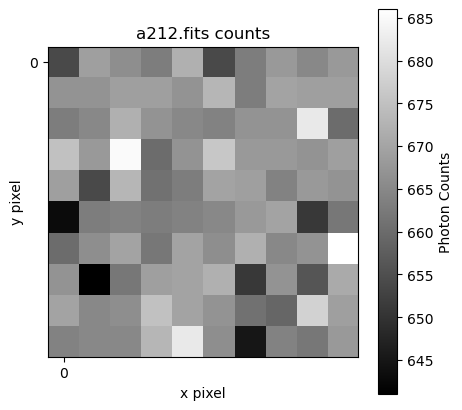

In [47]:
# Defining plot size and image dimensions
plot_size_attempt1 = (5, 5) # Width and height of the plot
img_dimensions_attempt1 = (30, 40, 10, 20) # Image dimensions: row min, row max, col min, col max

# Calling our new function with the specified parameters
rapid_fits_image_resizing(['a212.fits'], plot_size_attempt1, img_dimensions_attempt1)

WOAH!!! That's a super big close up! Let's zoom out a little...

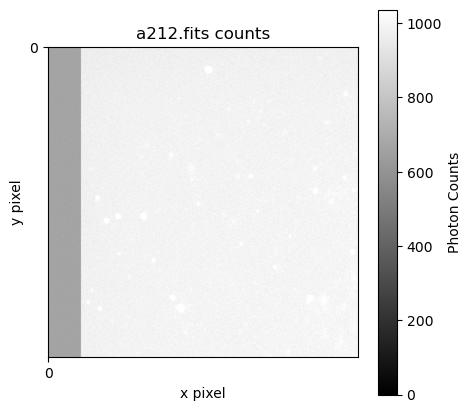

In [48]:
# Attempt 2:
plot_size_attempt2 = (5, 5) 
img_dimensions_attempt2 = (0, 500, 0, 500)
rapid_fits_image_resizing(['a212.fits'], plot_size_attempt2, img_dimensions_attempt2)

Hmmm... it seems like we need to re-edit the plotting function to make the pixels a little easier to see, as well as the right axes. Here's my go at it:

In [51]:
def plot_image_rescaled(filename, img, plot_size, img_dimensions):
    
    # Keeping the old scaling
    interval = ZScaleInterval() 
    vmin, vmax = interval.get_limits(img) 

    # Extracting the plot size
    width, height = plot_size

    # Extracting the image dimensions
    row_min, row_max, col_min, col_max = img_dimensions
    img_resized = img[row_min:row_max, col_min:col_max]
    ydim, xdim = img_resized.shape # Getting the dimensions of the resized image

    # Plotting our image
    fig = plt.subplots(1,1,figsize=(width, height))
    plt.imshow(img_resized, vmin=vmin, vmax=vmax, cmap='gray') # The plotting of the image with the color scaling we set above

    # Establisting the x and y ticks
    plt.xticks(np.arange(0, xdim, step=xdim/5)) # Setting the x ticks to be every 500 pixels
    plt.yticks(np.arange(0, ydim, step=ydim/5)) # Setting the y ticks to be every 500 pixels

    # Establishing the labels for the axes
    plt.xlabel('x pixel')
    plt.ylabel('y pixel')

    # Title, color bar, and grid
    plt.title(f'{filename} counts')
    plt.colorbar(label='Photon Counts')
    plt.grid(False)

    # Show the image
    plt.show()

And now we can do the image resizing IN the plotting function!

In [52]:
def rapid_fits_image_v4(filenames, plot_size, imgs_dimensions):
    
    # Plotting all the images we want (while doing the dimension resizing inside the plotter)
    for filename in filenames:
        _, _, img = open_image(data_dir, str(filename)) # Opening the image
        plot_image_rescaled(filename, img, plot_size, imgs_dimensions) # Plotting the image (with the specified dimensions!)

Here's my attempt at running it. With me luck!

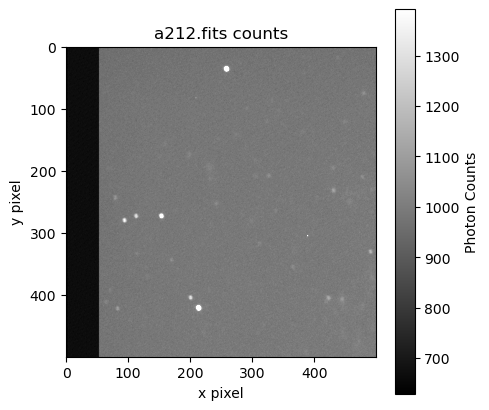

In [53]:
# Attempt 3:
plot_size_attempt3 = (5, 5)
img_dimensions_attempt3 = (0, 500, 0, 500)
rapid_fits_image_v4(['a212.fits'], plot_size_attempt3, img_dimensions_attempt3)

WONDERFUL!! In celebration, here's a few more!

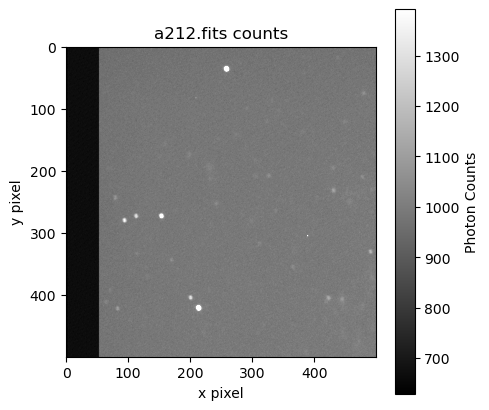

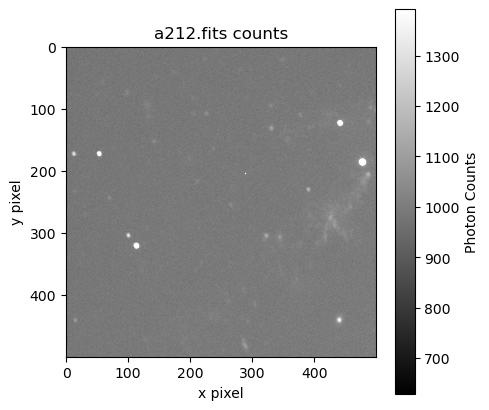

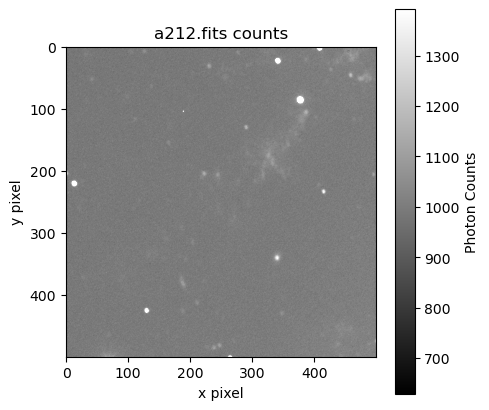

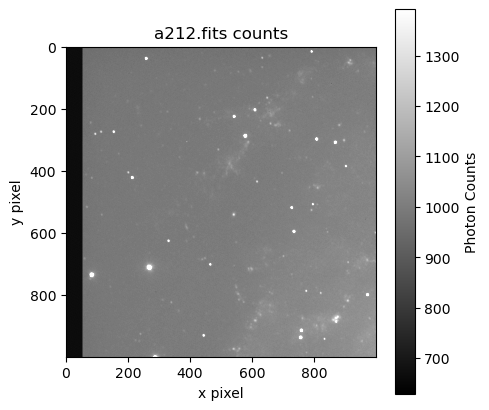

In [55]:
# Doing a bunch of different a212 image dimensions to showcase my function!! WOOOOOHOOOOOO
plot_size_success1 = (5, 5)
a212_dims_list1 = [(0, 500, 0, 500), (100, 600, 100, 600), (200, 700, 200, 700), (0, 1000, 0, 1000)]
for dims in a212_dims_list1:
    rapid_fits_image_v4(['a212.fits'], plot_size_success1, dims)


Nice! Now, let's try and do a specific row and column! From the image combination notebook, we know that we want either the row or column max and mins to be one apart, which will select that specifc row/column. Here's my attempt at this:

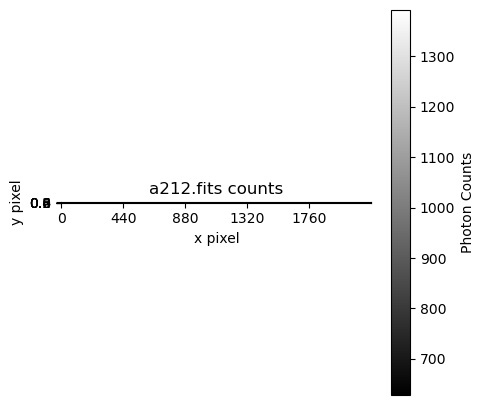

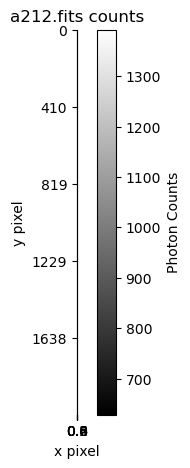

In [ ]:
# Rows and columns attempts 1:
a212_dims_list2 = [(0, 1, 0, 2200), (0, 2048, 0, 1)]
for dims in a212_dims_list2:
    rapid_fits_image_v4(['a212.fits'], plot_size_success1, dims)

Wow that's ugly! Let's try to increase the size of our image to see if we can see this:

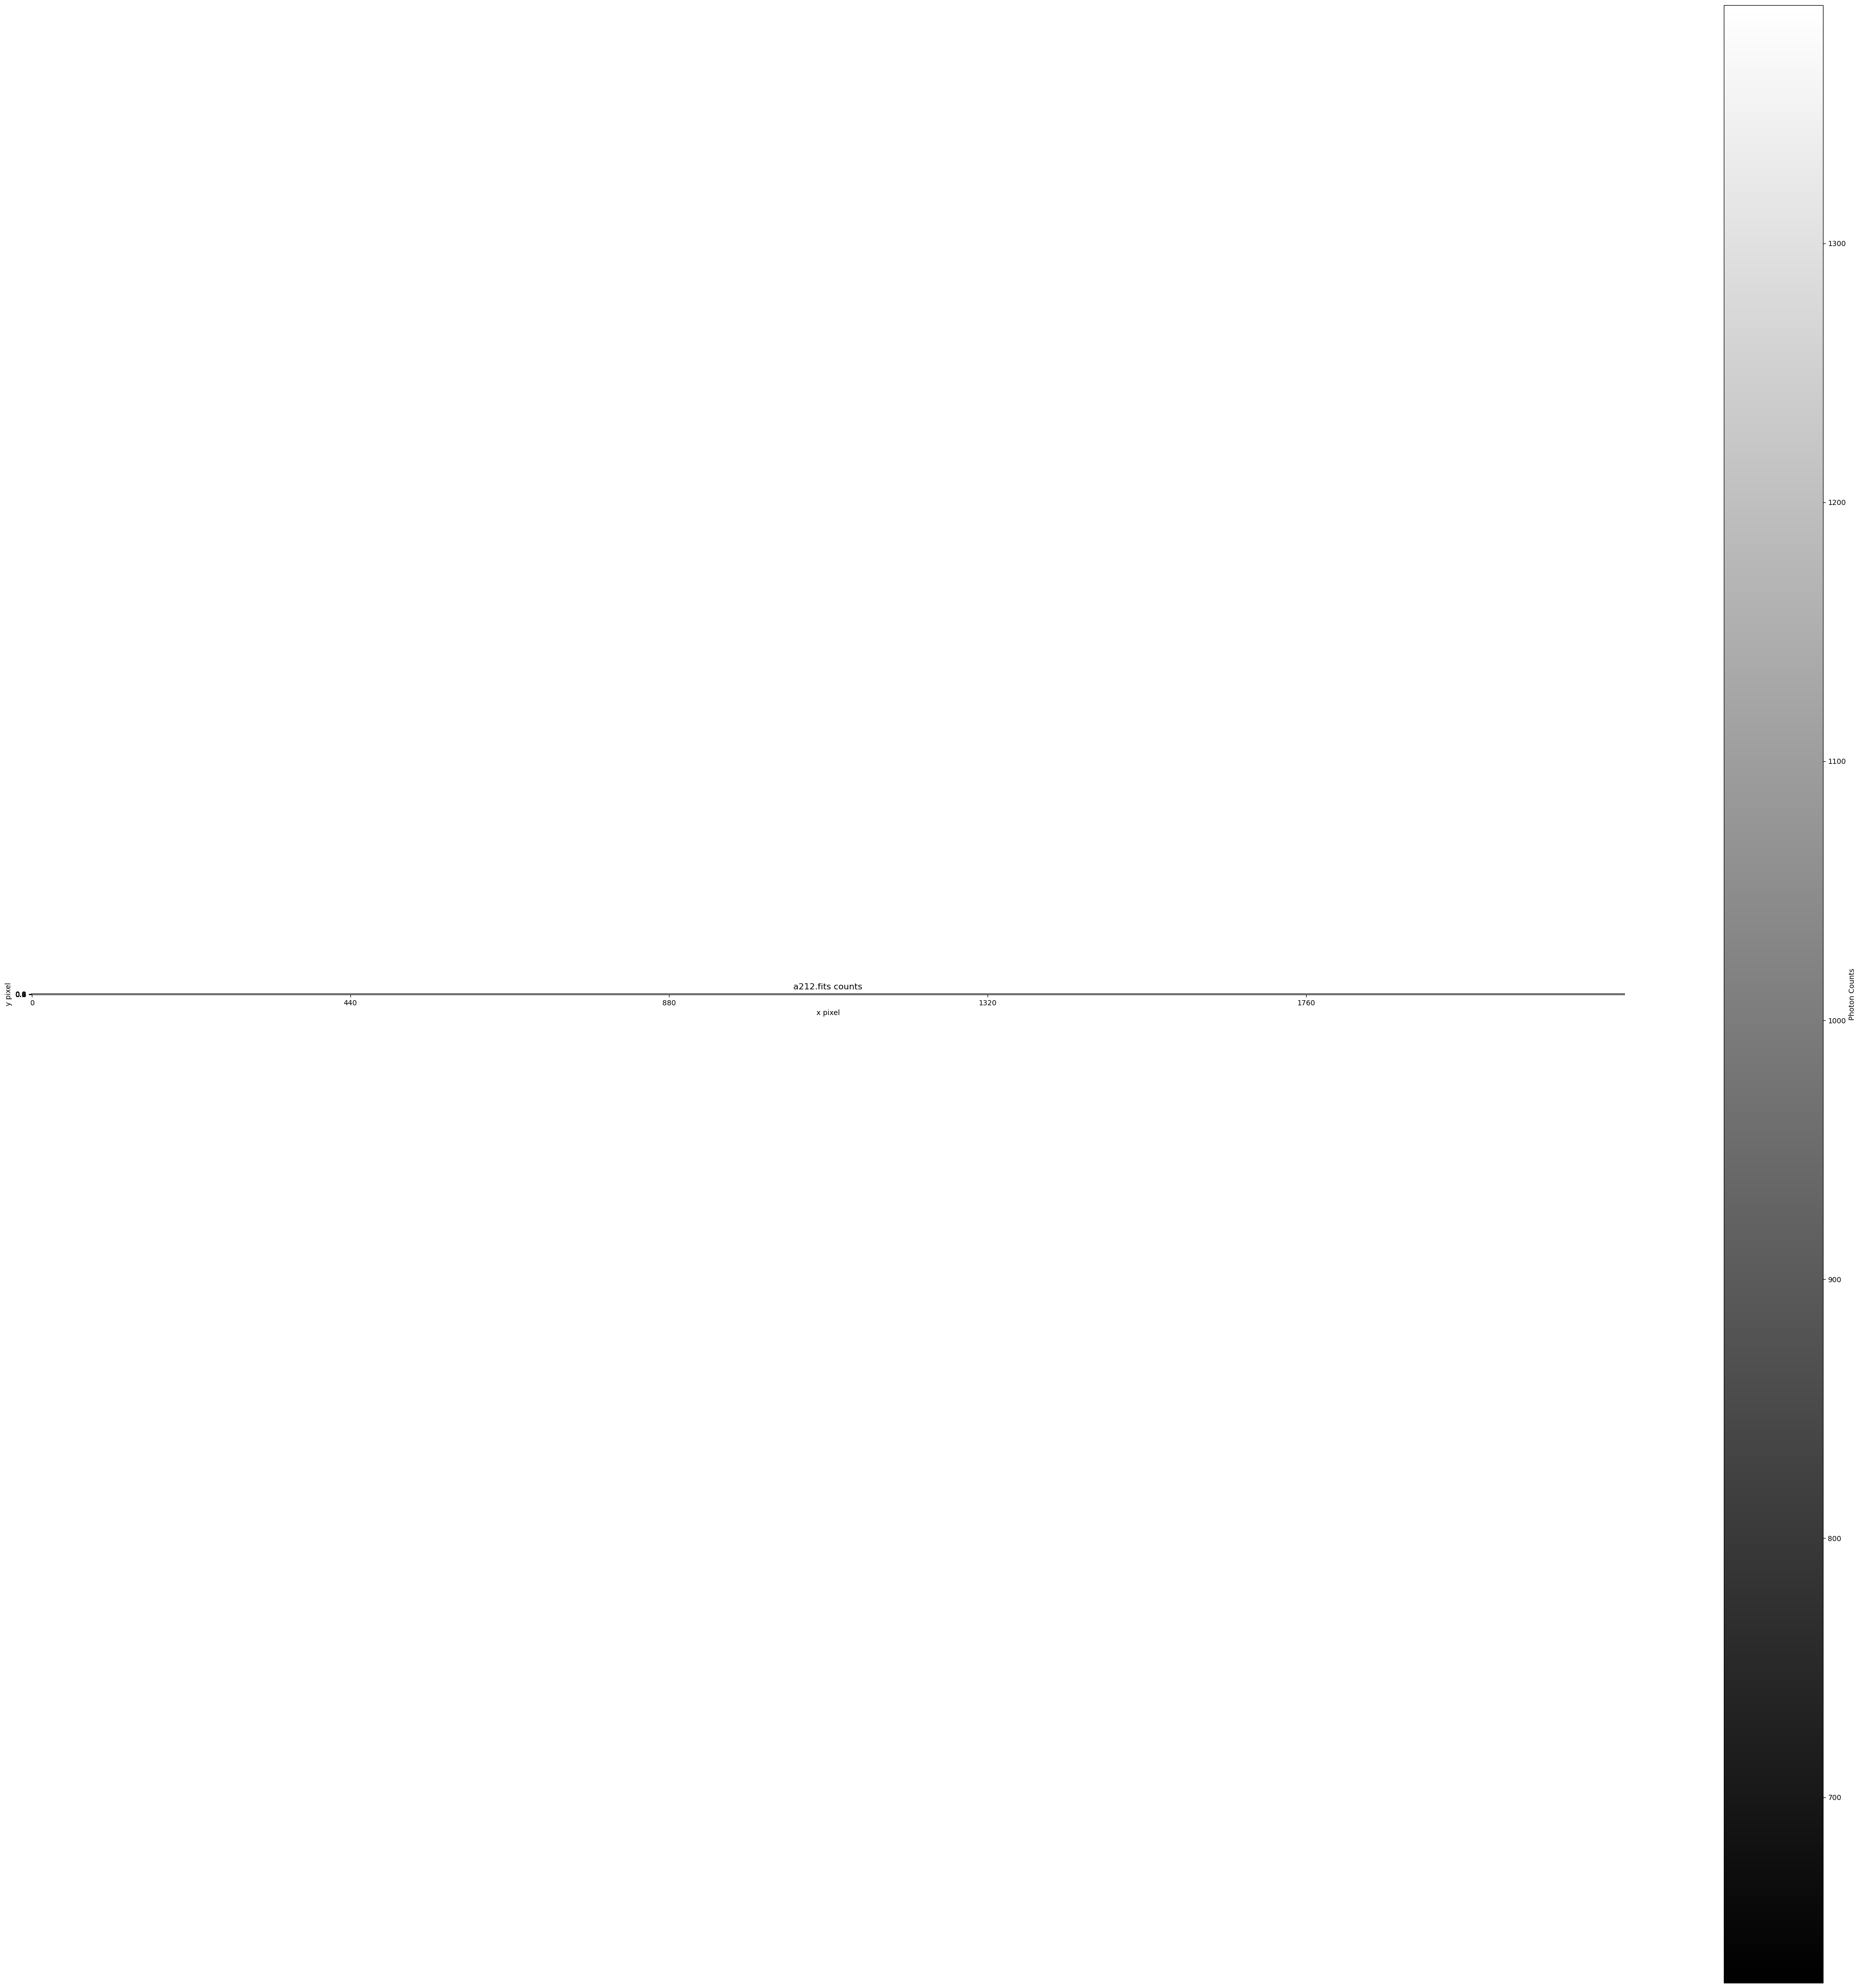

In [ ]:
# Attempt 2 at making this shit visible:
plot_size_row = (50, 50)
a212_dims_list2 = [(0, 1, 0, 2200)]
for dims in a212_dims_list2:
    rapid_fits_image_v4(['a212.fits'], plot_size_row, dims)

This isn't really working as planned. I think a better approach would be to plot this as a histogram with the y-axis being the photon counts. Why not?

In [64]:
def plot_image_line_histogram(filename, img, plot_size, img_dimensions):
    
    # Extracting the plot size
    width, height = plot_size

    # Extracting the image dimensions
    row_below, row_above, col_below, col_above = img_dimensions
    img_resized = img[row_below:row_above, col_below:col_above]
    rows, columns = img_resized.shape # Getting the dimensions of the resized image

    # Plotting our image (choice between row and column)
    fig = plt.subplots(1,1,figsize=(width, height))
    if row_above - row_below == 1:
        plt.hist(img_resized.flatten(), bins=rows, alpha=0.75)
        plt.title(f'{filename} counts along row {row_above}')
    else:
        plt.hist(img_resized.flatten(), bins=columns, alpha=0.75)
        plt.title(f'{filename} counts along column {col_above}')
    
    # Finishing touches
    plt.xlabel('Pixel Value')
    plt.ylabel('Photon Count')
    plt.show()

Nice! Defining a new function for ease of use (maybe want to make a class and put these methods in as I go along? We'll see):

In [65]:
def rapid_fits_histogram(filename, plot_size, imgs_dimensions):
    _, _, img = open_image(data_dir, str(filename)) 
    plot_image_line_histogram(filename, img, plot_size, imgs_dimensions) 

Alright! Let's try it!

In [72]:
# Rows and Columns Attempt 3
plot_size_rc_v3 = (5, 10)
a212_dims_rc_v3 = [(0, 1, 0, 2200)]
#rapid_fits_histogram('a212.fits', plot_size_rc_v3, a212_dims_rc_v3)
# Not working!!! Ugh

Hmmmm... not what I want either. Let's do some testing:

In [77]:
def plot_image_line_histogram_testing(filename, img, plot_size, img_dimensions):
    
    # Extracting the plot size
    width, height = plot_size

    # Extracting the image dimensions
    row_below, row_above, col_below, col_above = img_dimensions
    img_resized = img[row_below:row_above, col_below:col_above]
    rows, columns = img_resized.shape # Getting the dimensions of the resized image
    print(f"Resized image dimensions: {rows} rows, {columns} columns") # Debugging print statement

    # Plotting our image (choice between row and column)
    fig = plt.subplots(1,1,figsize=(width, height))
    if row_above - row_below == 1:
        plt.hist(img_resized.flatten(), bins=rows, alpha=0.75)
        plt.title(f'{filename} counts along row {row_above}')
    else:
        plt.hist(img_resized.flatten(), bins=columns, alpha=0.75)
        plt.title(f'{filename} counts along column {col_above}')
    
    # Finishing touches
    plt.xlabel('Pixel Value')
    plt.ylabel('Photon Count')
    #plt.show()

    # Success print
    print("Histogram plotted successfully!")

Now, I'd like to build a first-class object that takes in whatever function I want and does the thing I want with it. Here's my go at creating a generic fits file opener and plotter:

In [76]:
def rapid_fits_plotter(filename, plot_size, img_dimensions, func):
    _, _, img = open_image(data_dir, str(filename)) 
    func(filename, img, plot_size, img_dimensions) 

Nice! Now, let's try our test...

In [ ]:
#rapid_fits_plotter('a212.fits', plot_size_rc_v3, a212_dims_rc_v3, plot_image_line_histogram_testing)

ValueError: not enough values to unpack (expected 4, got 1)

Okay... it's having some sort of problem with line 7 in plot_image_line_histogram_testing. I'm going to try NOT passing it as a list and just as the four values. Here's my go at this:

Resized image dimensions: 1 rows, 2200 columns
Histogram plotted successfully!


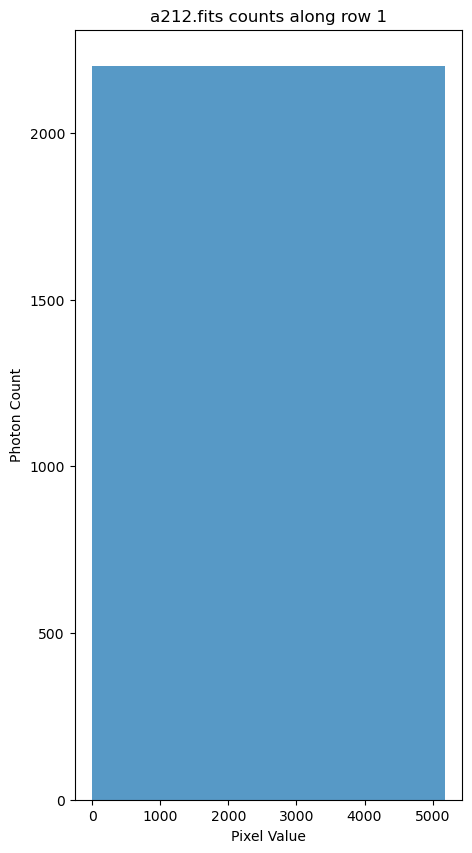

In [78]:
a212_dims_rc_notlist = [0, 1, 0, 2200]
rapid_fits_plotter('a212.fits', plot_size_rc_v3, a212_dims_rc_notlist, plot_image_line_histogram_testing)

That's odd... it made the plot anyway, and I'm still getting the same problem! I'm probably going to come back tomorrow for this (since it's 3:26 pm) so I can focus on some research. See you then!

Actually I lied. One more thing before I stop working for the day: in the image combination notebook, we have a bit of code for plotting this bin stuff. Let's give it a shot!

In [82]:
def imgcombo_hist_technique(filename):

    _, _, img = open_image(data_dir, filename)
    #hdu = fits.open(data_dir + 'a238.fits')
    # Maybe here we can do the image resizing? That way it'll be a 1D line of values for either a row or column!!!

    collapsed_counts = img.flatten()
    low_limit1 = np.percentile(collapsed_counts, 1)
    hi_limit1 = np.percentile(collapsed_counts, 99)
    bins1 = np.histogram_bin_edges(collapsed_counts, bins=50, range=[low_limit1,hi_limit1])

    plt.figure(figsize=(6,6))
    plt.hist(collapsed_counts, bins=bins1, alpha=0.5, label=f'{filename}',rwidth=1)
    plt.legend()
    plt.xlim([low_limit1,hi_limit1])
    plt.xlabel('Counts')
    plt.ylabel('Number of pixels')
    plt.show()

Trying it out on our file:

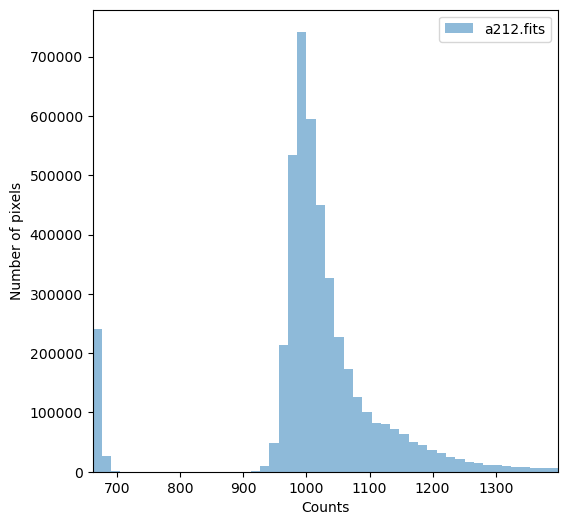

In [83]:
imgcombo_hist_technique('a212.fits')

Nice! I think my job for tomorrow is to switch around counts/# of pixels, and then put the image resizing technique to get each individual row inside my new function. I'll also just open the fits file inside the function I'm going to use anyway since it saves a good bit of hassle.

To-Do tmrw:
- Remake the imgcombo_hist_technique function for this homework (switch axes and do the rows/columns resizing).
- Try out a few rows/columns to check your code works.
- Compute mean and RMS of a region near the center of our image.

Sounds good! See ya tomorrow!

--------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 4): Open Phillip Massey’s users’s guide to ccd reductions with IRAF, linked on the class website. Use this as a rough guide, but we won’t follow everything he recommends (there are just too many ways to do the same thing!). An example of these steps in action can be found at the CCD reduction and photometry guide Github tutorial also linked from the class website.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 5): Examine the all bias exposures (or overscan regions throughout the night) and quantify how much the bias level changes throughout the night. Compare the mean level of the biases to the mean levels of the overscan regions from other files throughout the night. How much variation do you find? Make an argument for whether it would be a good or bad idea to combine all of the biases to make a master bias and subtract that from all the images versus using the overscan region of each image as an estimate of the bias level.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 6): Using CCDPROC.SUBTRACT_OVERSCAN and CCDPROC.TRIM_IMAGE, fit and subtract the overscan region of each image and trim the image to remove the overscan region. In the overscan fitting, try out ’chebyshev’, ’legendre’, and ’hermite’, and ’polynomial’ of various orders for the fitting function. Qualitatively try to summarize the differences between the functions (you can also look up and summarize the properties of these types of polynomials, but this is not required). Also try orders 1 through about 8, and make an argument for how large an order is necessary to fit the overscan region.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 7): Combine the bias frames into a master bias frame using CCDPROC.COMBINE. By visual inspection or using image statistics, decide whether it is appropriate to combine all your bias exposures to make 1 master bias, or whether you need to restrict the input frames because of variations among your bias frames. Are there trends in your sequence of bias frames? Does either the level, or the pattern of the bias change throughout the night? If so, by how much? How much noise would you be adding to your data if you decide to do a bias subtraction in addition to your overscan subtraction. Do the subtraction of your master bias from all other science frames if you can justify that it is warranted.



--------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 8). Now examine the ‘dark’ images quantitatively and estimate the range of dark current (electrons per pixel per second) you see in the darks. WIRO Prime’s gain is 2.5 e−/ADU. Use Python to inspect the header and see the exposure time in each of the darks. Pixel values will vary! Be careful to avoid being fooled by cosmic rays, which will appear as large bright spots usually spread over a few pixels, whereas high dark current is usually isolated to just individual pixels.


--------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 9). Use CCDPROC.COMBINE to combine darks together to make a master dark. You will need to play with different combination parameters to see which one does the best job of eliminating cosmic rays. At a minimum, do:
## • A straight average of all dark frames.
## • A straight median of all dark frames.
## • An average where outlier pixels are rejected if they are more than 3σ away from the mean.
## • A median where outlier pixels are rejected if they are more than 3σ away from the mean.
## Use the resulting RMS in the master image as an indicator of which combination procedure is best. Compare your master dark to your master bias to estimate the significance of the highest dark count pixels. How many times larger is the typical dark current than the noise (σ) in the master image?